In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

def simulate_two_photon_dicke(N, M, wc, wa, kappa_1, kappa_2, lam):
    """
    Simulates the driven-dissipative two-photon Dicke model.
    
    Parameters:
    N (int): Number of spins (system size)
    M (int): Cavity Fock space truncation
    wc (float): Cavity resonance frequency
    wa (float): Emitter resonance frequency
    kappa_1 (float): Single-photon loss rate
    kappa_2 (float): Two-photon loss rate
    lam (float): Light-matter coupling strength
    """
    # 1. Define the Hilbert space dimensions and operators
    j = N / 2.0
    dim_spin = int(2 * j + 1) # Size of the spin Hilbert space scales linearly [cite: 53]
    
    # Annihilation operator for the cavity mode
    a = qt.tensor(qt.destroy(M), qt.qeye(dim_spin))
    
    # Collective spin operators
    Jx = qt.tensor(qt.qeye(M), qt.jmat(j, 'x'))
    Jy = qt.tensor(qt.qeye(M), qt.jmat(j, 'y'))
    Jz = qt.tensor(qt.qeye(M), qt.jmat(j, 'z'))
    
    # 2. Construct the Hamiltonian
    # H = wc*a^dag a + (wa/2)*Jz + (lambda/N)*Jx*(a^dag^2 + a^2)
    H_cavity = wc * a.dag() * a
    H_atom = (wa / 2.0) * Jz
    H_int = (lam / N) * Jx * (a.dag()**2 + a**2)
    H = H_cavity + H_atom + H_int
    
    # 3. Construct the Lindblad Jump Operators (Collapse Operators)
    c_ops = []
    
    # Single-photon loss: L1 = sqrt(kappa_1) * a
    if kappa_1 > 0:
        L1 = np.sqrt(kappa_1) * a
        c_ops.append(L1)
        
    # Two-photon loss: L2 = sqrt(kappa_2 / N) * a^2
    if kappa_2 > 0:
        L2 = np.sqrt(kappa_2 / N) * (a**2)
        c_ops.append(L2)
        
    # 4. Diagonalize the Liouvillian to find the steady state (rho_ss)
    # QuTiP's steadystate solver builds the Liouvillian matrix and finds its zero eigenvector
    print('Finding rho')
    rho_ss = qt.steadystate(H, c_ops)
    
    # 5. Extract Observables
    # Average photon number scaled by N
    n_avg = qt.expect(a.dag() * a, rho_ss) / N
    
    # Average collective spin components scaled by N
    jx_avg = qt.expect(Jx, rho_ss) / N
    jz_avg = qt.expect(Jz, rho_ss) / N
    
    # Photon probability distribution P(n)
    # Trace out the spin degrees of freedom to get the reduced cavity density matrix
    rho_cavity = rho_ss.ptrace(0)
    P_n = rho_cavity.diag()
    
    return n_avg, jx_avg, jz_avg, P_n, rho_ss

# --- Execution and Plotting ---


"""
# Sweep coupling strength lambda
lambda_vals = np.linspace(0.0, 2.0, 20)
photons_ss = []

print("Simulating steady states...")
for lam in lambda_vals:
    n_avg, _, _, _ = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam)
    photons_ss.append(n_avg)

# Plotting the steady-state photon number vs coupling strength
plt.figure(figsize=(8, 5))
plt.plot(lambda_vals, photons_ss, marker='o', label=f'N={N_spins}, M={M_fock}')
plt.axvline(x=0.5, color='green', linestyle='--', label='Theoretical Critical Point')
plt.xlabel('Coupling Strength $\lambda / \omega_c$')
plt.ylabel('Average Photons $\langle a^\dagger a \\rangle / N$')
plt.title('Stabilized Dissipative Phase Transition')
plt.legend()
plt.grid(True)
plt.show()
"""

# Get the photon distribution P(n) at a strong coupling regime


'\n# Sweep coupling strength lambda\nlambda_vals = np.linspace(0.0, 2.0, 20)\nphotons_ss = []\n\nprint("Simulating steady states...")\nfor lam in lambda_vals:\n    n_avg, _, _, _ = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam)\n    photons_ss.append(n_avg)\n\n# Plotting the steady-state photon number vs coupling strength\nplt.figure(figsize=(8, 5))\nplt.plot(lambda_vals, photons_ss, marker=\'o\', label=f\'N={N_spins}, M={M_fock}\')\nplt.axvline(x=0.5, color=\'green\', linestyle=\'--\', label=\'Theoretical Critical Point\')\nplt.xlabel(\'Coupling Strength $\\lambda / \\omega_c$\')\nplt.ylabel(\'Average Photons $\\langle a^\\dagger a \\rangle / N$\')\nplt.title(\'Stabilized Dissipative Phase Transition\')\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [9]:
# Parameters used in the paper for the instability demonstration (Fig 2)
N_spins = 4         # N = 4 spins [cite: 94]
M_fock = 60         # M = 60 Fock states [cite: 94]
omega_c = 1.0       # Cavity frequency [cite: 96]
omega_a = 1.0       # Atom frequency [cite: 96]
k1 = 0.4            # One-photon loss [cite: 96]
k2 = 0.05           # Two-photon loss (Added to stabilize the system [cite: 222])

Finding rho


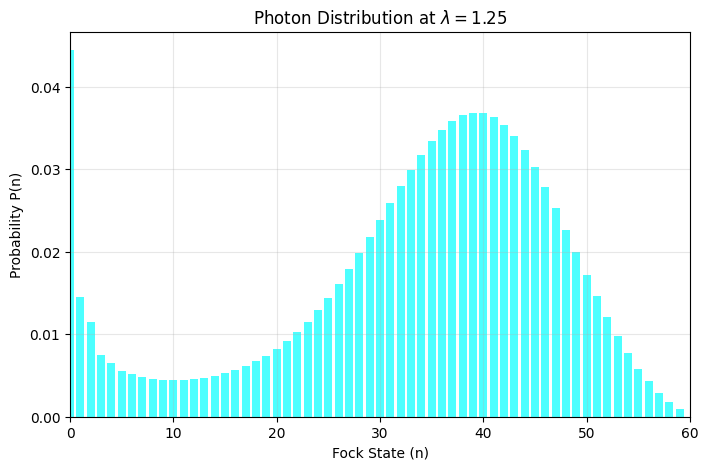

In [10]:
lam_strong =1.25
a, b, c, P_n, test_ss = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam_strong)

plt.figure(figsize=(8, 5))
plt.bar(range(M_fock), P_n[:M_fock], color='cyan', alpha=0.7)
plt.xlabel('Fock State (n)')
plt.ylabel('Probability P(n)')
plt.title(f'Photon Distribution at $\lambda={lam_strong}$')
plt.xlim(0, M_fock)
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
def plot_wigner_function(rho_ss, x_max=15, points=200):
    """
    Calculates and plots the Wigner function for the cavity mode.
    
    Parameters:
    rho_ss: The steady-state density matrix of the full system.
    x_max: The limits for the X and P phase space axes.
    points: The resolution of the phase space grid.
    """
    # 1. Trace out the spins to get the cavity's reduced density matrix
    rho_cavity = rho_ss.ptrace(0)
    
    # 2. Define the phase space grid axes (X and P)
    # The paper plots from -15 to 15 
    xvec = np.linspace(-x_max, x_max, points)
    pvec = np.linspace(-x_max, x_max, points)
    
    # 3. Calculate the Wigner function
    W = qt.wigner(rho_cavity, xvec, pvec)
    
    # 4. Plotting
    plt.figure(figsize=(6, 6))
    
    # Using 'Blues' colormap to match the style of Fig. 4 in the paper
    # vmin=0 ensures the white background maps to zero probability
    plt.pcolormesh(xvec, pvec, W, cmap='Blues', shading='auto', vmin=0)
    
    plt.xlabel('X')
    plt.ylabel('P')
    plt.title('Photonic Wigner Function')
    
    # Set ticks to match the paper's style (-15, 0, 15)
    plt.xticks([-x_max, 0, x_max])
    plt.yticks([-x_max, 0, x_max])
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# --- Example Usage (Using your previously fixed solver) ---

# Parameters matching Figure 4(b) from the paper


Finding rho


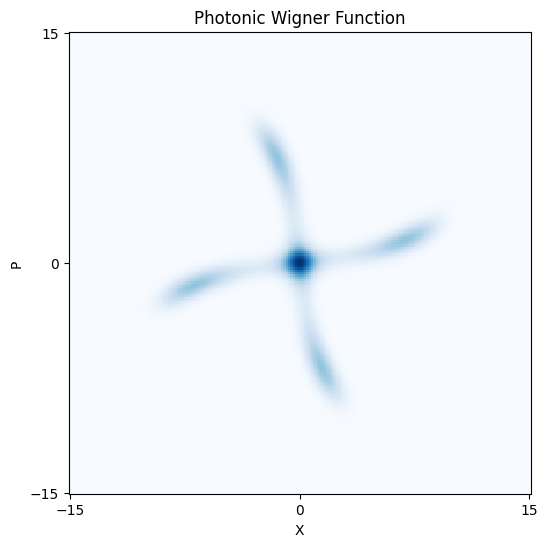

In [12]:
N_spins = 5         # System size 
M_fock = 80         # Ensure this is high enough for convergence
omega_c = 1.0
omega_a = 1.0
k1 = 0.4
k2 = 0.05
lam_val = 1.1      # Coupling strength for the 4-lobe superradiant state

a, b, c, P_n, test_ss = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam_val)
plot_wigner_function(test_ss, x_max=15)

Finding rho


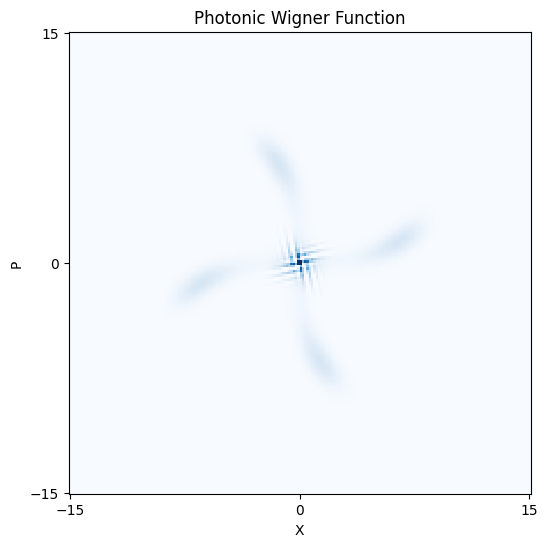

In [3]:
N_spins = 5         # System size 
M_fock = 100        # Ensure this is high enough for convergence
omega_c = 1.0
omega_a = 1.0
k1 = 0.0
k2 = 0.1
lam_val = 1.1      # Coupling strength for the 4-lobe superradiant state

a, b, c, P_n, test_ss = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam_val)
plot_wigner_function(test_ss, x_max=15)